# R Programming — Basics & Weather Data Analysis

This notebook covers:
1. Conditional statements
2. Functions
3. Loops
4. Loading and exploring `weather.json`
5. Statistical description
6. Linear regression for prediction

## Setup — Install Required Packages

Run the cell below **once** before starting. It installs all packages needed for this notebook.


In [2]:
# Run this cell once to install all required packages
pkgs <- c("jsonlite", "ggplot2")
install.packages(pkgs[!pkgs %in% installed.packages()[, "Package"]],
                 repos = "https://cloud.r-project.org")


## 1. Conditional Statements

R supports `if`, `else if`, and `else`. Conditions use standard comparison operators (`==`, `!=`, `<`, `>`, `<=`, `>=`) and logical operators (`&`, `|`, `!`).

In [3]:
temp <- 35

# Basic if / else if / else
if (temp > 40) {
  cat("Extreme heat\n")
} else if (temp > 30) {
  cat("Hot day\n")
} else if (temp > 20) {
  cat("Warm day\n")
} else {
  cat("Cool or cold\n")
}

# Logical operators: AND (&), OR (|), NOT (!)
humidity <- 80
if (temp > 30 & humidity > 70) {
  cat("Hot and humid -- feels oppressive\n")
}

rain_today <- "Yes"
if (rain_today == "Yes" | temp < 10) {
  cat("Bring a jacket\n")
}

# Vectorised ifelse() -- works element-wise on vectors
temps <- c(12, 25, 38, 5, 30)
labels <- ifelse(temps > 28, "Hot", "Not hot")
print(labels)


Hot day
Hot and humid -- feels oppressive
Bring a jacket
[1] "Not hot" "Not hot" "Hot"     "Not hot" "Hot"    


## 2. Functions

Functions are defined with `function()`. R returns the last evaluated expression automatically, or you can use `return()` explicitly.

In [4]:
# Basic function with return value
celsius_to_fahrenheit <- function(c) {
  return(c * 9 / 5 + 32)
}
cat("25°C =", celsius_to_fahrenheit(25), "°F\n")

# Default arguments
describe_temp <- function(temp, unit = "C") {
  label <- ifelse(temp > 30, "hot", ifelse(temp > 15, "warm", "cold"))
  cat(sprintf("%.1f°%s is %s\n", temp, unit, label))
}
describe_temp(35)
describe_temp(68, unit = "F")

# Function returning multiple values as a list
temp_stats <- function(temps) {
  list(
    mean   = mean(temps),
    sd     = sd(temps),
    min    = min(temps),
    max    = max(temps),
    range  = max(temps) - min(temps)
  )
}

stats <- temp_stats(c(12, 18, 25, 33, 29, 14))
print(stats)

25<U+00B0>C = 77 <U+00B0>F
35.0<U+00B0>C is hot
68.0<U+00B0>F is hot
$mean
[1] 21.83333

$sd
[1] 8.471521

$min
[1] 12

$max
[1] 33

$range
[1] 21



## 3. Loops

R has `for`, `while`, and `repeat` loops. Use `next` to skip an iteration and `break` to exit early.

In [5]:
# --- for loop ---
days <- c("Mon", "Tue", "Wed", "Thu", "Fri")
for (day in days) {
  cat("Day:", day, "\n")
}

# for with next (skip) and break (exit)
cat("\nPrinting only even numbers up to 10, stopping at 8:\n")
for (i in 1:10) {
  if (i %% 2 != 0) next   # skip odd
  if (i > 8) break         # stop after 8
  cat(i, "")
}
cat("\n")

# --- while loop ---
cat("\nCountdown:\n")
n <- 5
while (n > 0) {
  cat(n, "")
  n <- n - 1
}
cat("Go!\n")

# --- repeat loop (manual break required) ---
cat("\nFirst temp above 30:\n")
temps <- c(18, 22, 28, 31, 35)
i <- 1
repeat {
  if (temps[i] > 30) {
    cat("Found:", temps[i], "at index", i, "\n")
    break
  }
  i <- i + 1
}

Day: Mon 
Day: Tue 
Day: Wed 
Day: Thu 
Day: Fri 

Printing only even numbers up to 10, stopping at 8:
2 4 6 8 

Countdown:
5 4 3 2 1 Go!

First temp above 30:
Found: 31 at index 4 


## 4. Loading Weather Data

We use `jsonlite` to read the JSON file directly into a data frame, then inspect its structure.

> **Install required package** (run once if not already installed):
> ```r
> install.packages("jsonlite")
> ```


In [6]:
library(jsonlite)

# Load weather.json — adjust path if needed
df <- fromJSON("weather.json")

# Force numeric columns (some may have been read as character)
df$Sunshine      <- as.numeric(df$Sunshine)
df$WindGustSpeed <- as.numeric(df$WindGustSpeed)
df$WindSpeed9am  <- as.numeric(df$WindSpeed9am)

cat("Dimensions:", nrow(df), "rows x", ncol(df), "columns\n\n")

# Column names
cat("Columns:\n")
print(names(df))

# First rows
head(df[, c("MinTemp","MaxTemp","Rainfall","Humidity9am","Humidity3pm",
            "Pressure9am","Temp9am","Temp3pm","RainTomorrow")])

Warning message:
"NAs introducidos por coerci'on"
Warning message:
"NAs introducidos por coerci'on"
Warning message:
"NAs introducidos por coerci'on"


Dimensions: 366 rows x 22 columns

Columns:
 [1] "MinTemp"       "MaxTemp"       "Rainfall"      "Evaporation"  
 [5] "Sunshine"      "WindGustDir"   "WindGustSpeed" "WindDir9am"   
 [9] "WindDir3pm"    "WindSpeed9am"  "WindSpeed3pm"  "Humidity9am"  
[13] "Humidity3pm"   "Pressure9am"   "Pressure3pm"   "Cloud9am"     
[17] "Cloud3pm"      "Temp9am"       "Temp3pm"       "RainToday"    
[21] "RISK_MM"       "RainTomorrow" 


,MinTemp,MaxTemp,Rainfall,Humidity9am,Humidity3pm,Pressure9am,Temp9am,Temp3pm,RainTomorrow
,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,8.0,24.3,0.0,68,29,1019.7,14.4,23.6,Yes
2,14.0,26.9,3.6,80,36,1012.4,17.5,25.7,Yes
3,13.7,23.4,3.6,82,69,1009.5,15.4,20.2,Yes
4,13.3,15.5,39.8,62,56,1005.5,13.5,14.1,Yes
5,7.6,16.1,2.8,68,49,1018.3,11.1,15.4,No
6,6.2,16.9,0.0,70,57,1023.8,10.9,14.8,No


In [7]:
# Structure and base summary
str(df)
summary(df[, c("MinTemp","MaxTemp","Rainfall","Humidity9am","Humidity3pm","Pressure9am")])

'data.frame':	366 obs. of  22 variables:
 $ MinTemp      : num  8 14 13.7 13.3 7.6 6.2 6.1 8.3 8.8 8.4 ...
 $ MaxTemp      : num  24.3 26.9 23.4 15.5 16.1 16.9 18.2 17 19.5 22.8 ...
 $ Rainfall     : num  0 3.6 3.6 39.8 2.8 0 0.2 0 0 16.2 ...
 $ Evaporation  : num  3.4 4.4 5.8 7.2 5.6 5.8 4.2 5.6 4 5.4 ...
 $ Sunshine     : num  6.3 9.7 3.3 9.1 10.6 8.2 8.4 4.6 4.1 7.7 ...
 $ WindGustDir  : chr  "NW" "ENE" "NW" "NW" ...
 $ WindGustSpeed: num  30 39 85 54 50 44 43 41 48 31 ...
 $ WindDir9am   : chr  "SW" "E" "N" "WNW" ...
 $ WindDir3pm   : chr  "NW" "W" "NNE" "W" ...
 $ WindSpeed9am : num  6 4 6 30 20 20 19 11 19 7 ...
 $ WindSpeed3pm : int  20 17 6 24 28 24 26 24 17 6 ...
 $ Humidity9am  : int  68 80 82 62 68 70 63 65 70 82 ...
 $ Humidity3pm  : int  29 36 69 56 49 57 47 57 48 32 ...
 $ Pressure9am  : num  1020 1012 1010 1006 1018 ...
 $ Pressure3pm  : num  1015 1008 1007 1007 1018 ...
 $ Cloud9am     : int  7 5 8 2 7 7 4 6 7 7 ...
 $ Cloud3pm     : int  7 3 7 7 7 5 6 7 7 1 ...
 $ Temp

    MinTemp          MaxTemp         Rainfall       Humidity9am   
 Min.   :-5.300   Min.   : 7.60   Min.   : 0.000   Min.   :36.00  
 1st Qu.: 2.300   1st Qu.:15.03   1st Qu.: 0.000   1st Qu.:64.00  
 Median : 7.450   Median :19.65   Median : 0.000   Median :72.00  
 Mean   : 7.266   Mean   :20.55   Mean   : 1.428   Mean   :72.04  
 3rd Qu.:12.500   3rd Qu.:25.50   3rd Qu.: 0.200   3rd Qu.:81.00  
 Max.   :20.900   Max.   :35.80   Max.   :39.800   Max.   :99.00  
  Humidity3pm     Pressure9am    
 Min.   :13.00   Min.   : 996.5  
 1st Qu.:32.25   1st Qu.:1015.4  
 Median :43.00   Median :1020.1  
 Mean   :44.52   Mean   :1019.7  
 3rd Qu.:55.00   3rd Qu.:1024.5  
 Max.   :96.00   Max.   :1035.7  

## 5. Statistical Description

We compute descriptive statistics (mean, median, SD, variance, skewness, kurtosis) and visualise distributions and correlations with `ggplot2`.

> **Install required package** (run once if not already installed):
> ```r
> install.packages("ggplot2")
> ```


In [8]:
library(ggplot2)

# Select numeric columns of interest
num_cols <- c("MinTemp","MaxTemp","Rainfall","Evaporation",
              "Humidity9am","Humidity3pm","Pressure9am","Pressure3pm",
              "Temp9am","Temp3pm")
num_df <- df[, num_cols]

# --- Descriptive statistics via base R ---
desc_stats <- function(x) {
  x <- x[!is.na(x)]
  n    <- length(x)
  mn   <- mean(x)
  med  <- median(x)
  s    <- sd(x)
  v    <- var(x)
  # skewness and kurtosis (moment-based)
  skew <- mean(((x - mn) / s)^3)
  kurt <- mean(((x - mn) / s)^4) - 3   # excess kurtosis
  c(n = n, mean = round(mn,2), median = round(med,2),
    sd = round(s,2), var = round(v,2),
    skewness = round(skew,3), kurtosis = round(kurt,3))
}

stats_table <- t(sapply(num_df, desc_stats))
print(as.data.frame(stats_table))

              n    mean  median    sd    var skewness kurtosis
MinTemp     366    7.27    7.45  6.03  36.31   -0.004   -1.126
MaxTemp     366   20.55   19.65  6.69  44.76    0.348   -0.764
Rainfall    366    1.43    0.00  4.23  17.86    4.553   26.240
Evaporation 366    4.52    4.20  2.67   7.13    0.658   -0.209
Humidity9am 366   72.04   72.00 13.14 172.58   -0.140   -0.206
Humidity3pm 366   44.52   43.00 16.85 283.95    0.590    0.012
Pressure9am 366 1019.71 1020.15  6.69  44.71   -0.346   -0.075
Pressure3pm 366 1016.81 1017.40  6.47  41.85   -0.293   -0.036
Temp9am     366   12.36   12.55  5.63  31.71   -0.022   -0.971
Temp3pm     366   19.23   18.55  6.64  44.09    0.301   -0.686


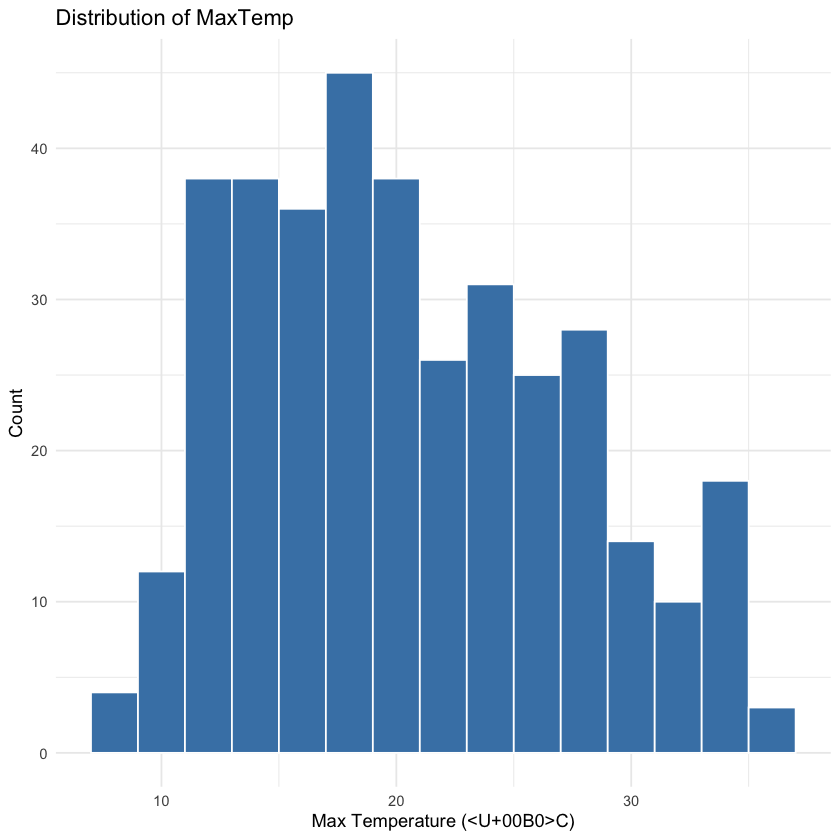

In [9]:
# Histogram of MaxTemp
ggplot(df, aes(x = MaxTemp)) +
  geom_histogram(binwidth = 2, fill = "steelblue", color = "white") +
  labs(title = "Distribution of MaxTemp", x = "Max Temperature (°C)", y = "Count") +
  theme_minimal()

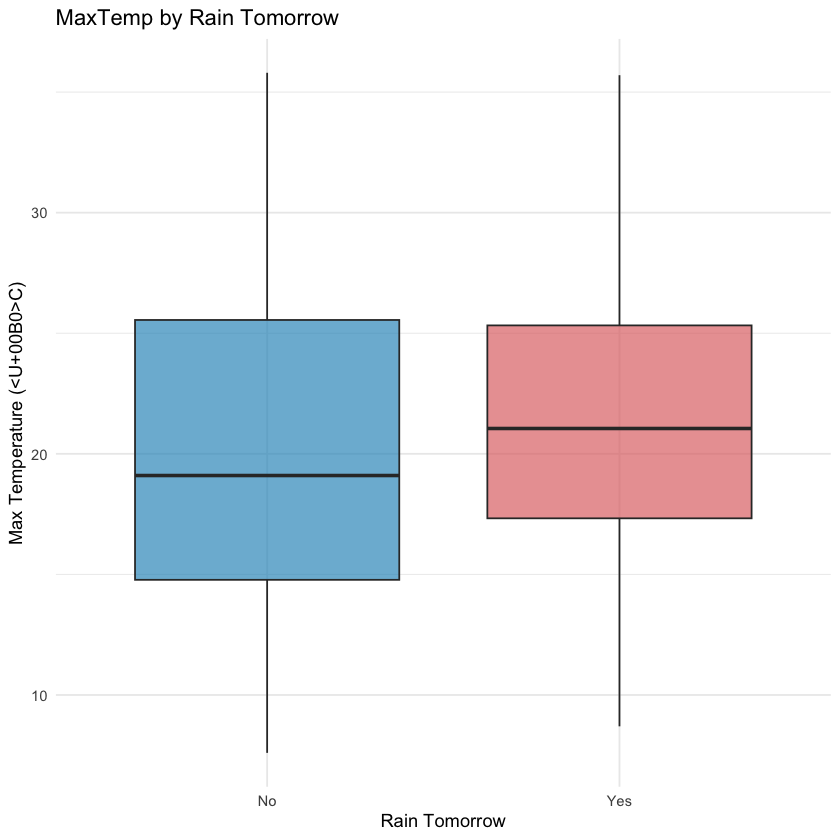

In [10]:
# Boxplot: temperature by RainTomorrow
ggplot(df, aes(x = RainTomorrow, y = MaxTemp, fill = RainTomorrow)) +
  geom_boxplot(alpha = 0.7) +
  scale_fill_manual(values = c("No" = "#3398c4", "Yes" = "#e07474")) +
  labs(title = "MaxTemp by Rain Tomorrow", x = "Rain Tomorrow", y = "Max Temperature (°C)") +
  theme_minimal() +
  theme(legend.position = "none")

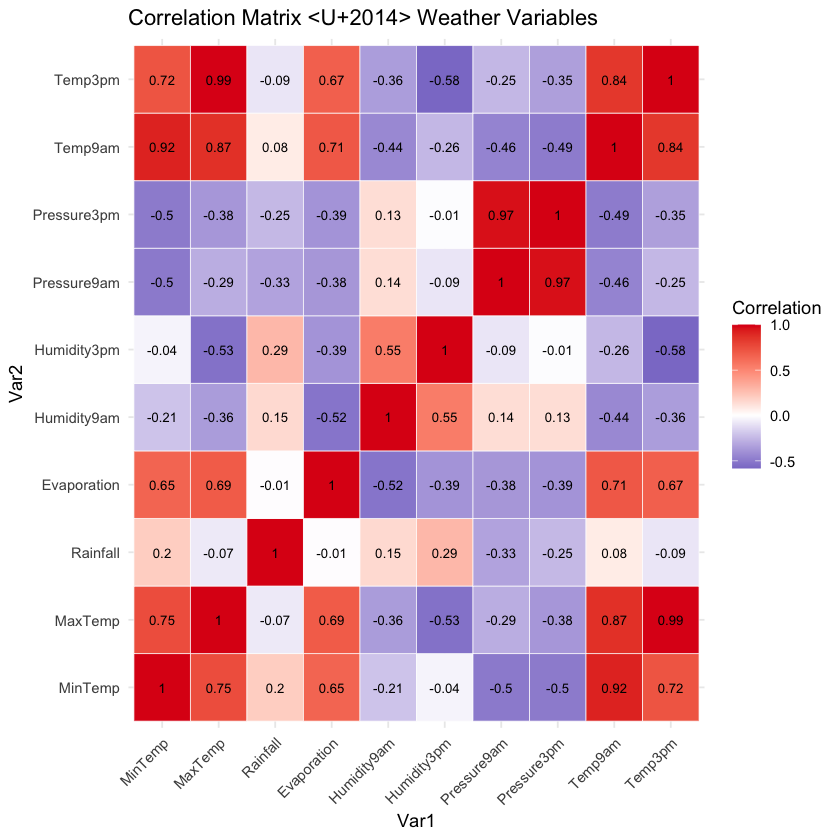

In [11]:
# Correlation matrix (pairwise complete observations)
cor_mat <- cor(num_df, use = "pairwise.complete.obs")

# Reshape for ggplot
cor_long <- as.data.frame(as.table(cor_mat))
names(cor_long) <- c("Var1", "Var2", "Correlation")

ggplot(cor_long, aes(Var1, Var2, fill = Correlation)) +
  geom_tile(color = "white") +
  scale_fill_gradient2(low = "#162ca9", mid = "white", high = "#de1616", midpoint = 0) +
  geom_text(aes(label = round(Correlation, 2)), size = 2.8) +
  labs(title = "Correlation Matrix — Weather Variables") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## 6. Linear Regression — Predicting MaxTemp

We build a multiple linear regression model with `lm()` to predict `MaxTemp` from `MinTemp`, `Humidity3pm`, `Pressure9am`, and `Sunshine`. The data is split 80/20 into training and test sets, and the model is evaluated with RMSE and R².

In [12]:
# Keep only rows with no NA in the columns we need
model_df <- df[, c("MaxTemp","MinTemp","Humidity3pm","Pressure9am","Sunshine")]
model_df  <- na.omit(model_df)

cat("Rows available for modelling:", nrow(model_df), "\n")

# --- Train / test split (80 / 20) ---
set.seed(42)
n        <- nrow(model_df)
train_idx <- sample(seq_len(n), size = floor(0.8 * n))
train    <- model_df[train_idx, ]
test     <- model_df[-train_idx, ]

# --- Fit the model ---
model <- lm(MaxTemp ~ MinTemp + Humidity3pm + Pressure9am + Sunshine, data = train)
summary(model)

Rows available for modelling: 363 



Call:
lm(formula = MaxTemp ~ MinTemp + Humidity3pm + Pressure9am + 
    Sunshine, data = train)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.5787 -1.7378  0.1707  2.0257  6.5637 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -25.67354   29.77858  -0.862   0.3893    
MinTemp       0.82060    0.03170  25.886   <2e-16 ***
Humidity3pm  -0.16647    0.01563 -10.648   <2e-16 ***
Pressure9am   0.04516    0.02892   1.562   0.1195    
Sunshine      0.19260    0.07313   2.634   0.0089 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.763 on 285 degrees of freedom
Multiple R-squared:  0.8236,	Adjusted R-squared:  0.8211 
F-statistic: 332.6 on 4 and 285 DF,  p-value: < 2.2e-16


In [16]:
# --- Evaluate on test set ---
predictions <- predict(model, newdata = test)

# RMSE and R²
rmse <- sqrt(mean((test$MaxTemp - predictions)^2))
ss_res <- sum((test$MaxTemp - predictions)^2)
ss_tot <- sum((test$MaxTemp - mean(test$MaxTemp))^2)
r2   <- 1 - ss_res / ss_tot

cat(sprintf("Test RMSE : %.3f C\n", rmse))
cat(sprintf("Test R²   : %.4f\n", r2))

Test RMSE : 3.037 C
Test R<U+00B2>   : 0.8275


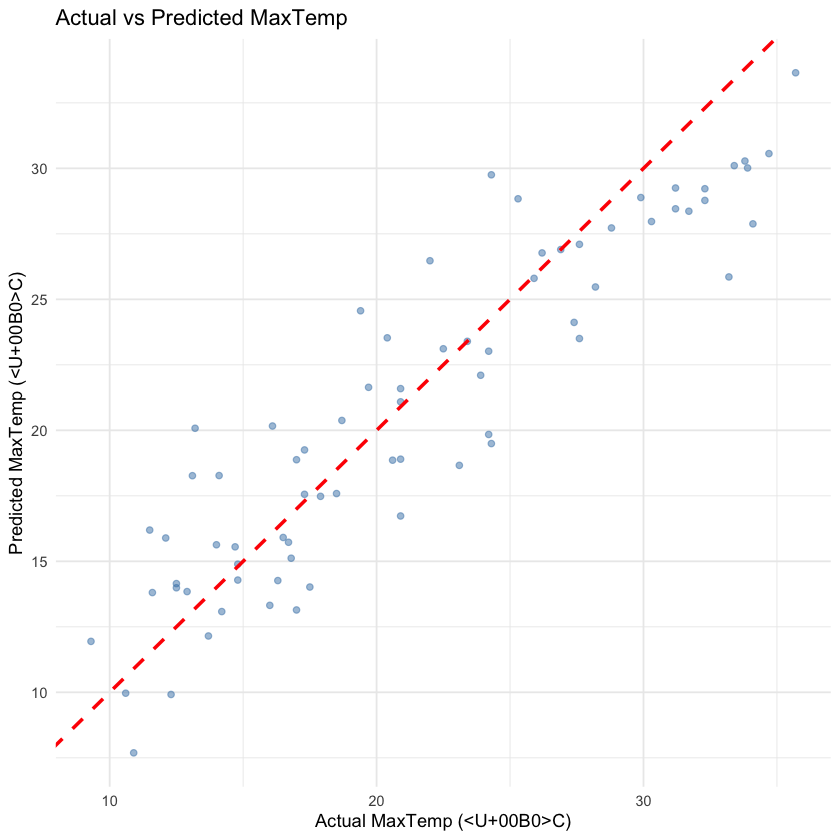

In [14]:
# --- Actual vs Predicted scatter plot ---
results <- data.frame(actual = test$MaxTemp, predicted = predictions)

ggplot(results, aes(x = actual, y = predicted)) +
  geom_point(alpha = 0.5, color = "steelblue") +
  geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed", linewidth = 1) +
  labs(
    title = "Actual vs Predicted MaxTemp",
    x = "Actual MaxTemp (°C)",
    y = "Predicted MaxTemp (°C)"
  ) +
  theme_minimal()

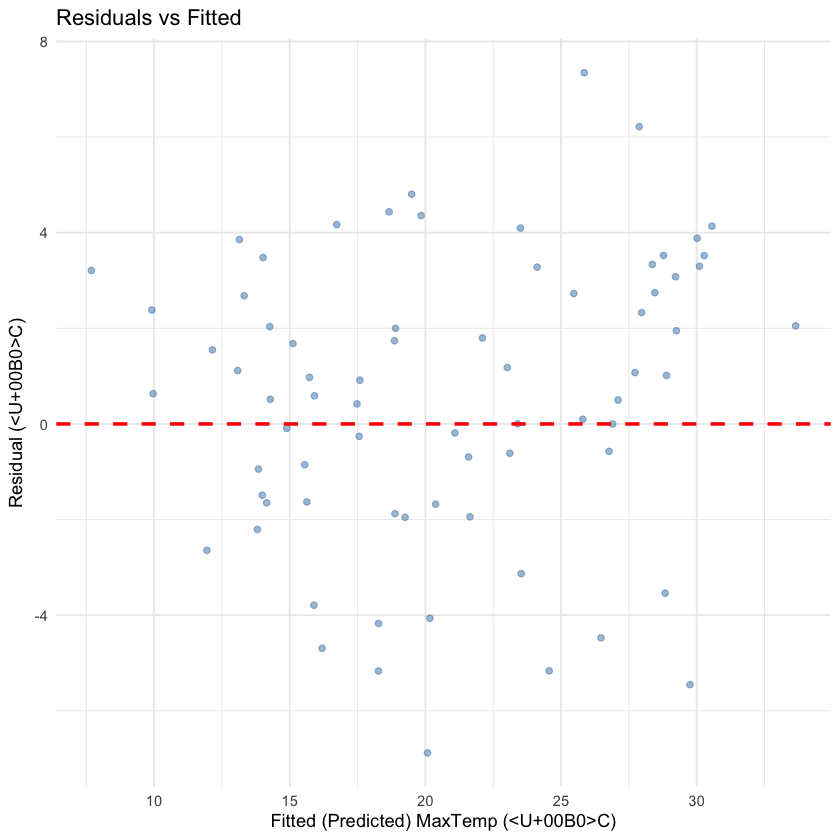

In [15]:
# --- Residuals plot ---
results$residual <- results$actual - results$predicted

ggplot(results, aes(x = predicted, y = residual)) +
  geom_point(alpha = 0.5, color = "steelblue") +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed", linewidth = 1) +
  labs(
    title = "Residuals vs Fitted",
    x = "Fitted (Predicted) MaxTemp (°C)",
    y = "Residual (°C)"
  ) +
  theme_minimal()